# Générateur de données — Formation Causalité

Notebook de génération de données simulées illustrant quatre biais causaux classiques.
Tous les paramètres de simulation se trouvent dans la cellule **PARAMÈTRES** ci-dessous.

**Usage :** Kernel → Restart & Run All — aucune modification nécessaire hors de la cellule Paramètres.

---
Scénarios couverts :
- **Scénario 0** — Biais de petits nombres (variance binomiale)
- **Scénarios 1a/1b/1c** — Biais de sélection (confondant)
- **Scénario 2** — Surcontrôle sur un médiateur
- **Scénario 3** — Surcontrôle sur un collider

In [1]:
# ═══════════════════════════════════════════════════════════
# PARAMÈTRES — modifiez ici uniquement
# ═══════════════════════════════════════════════════════════

SEED        = 42
N_MAGASINS  = 200
T_MOIS      = 24

N_PETIT  = 30
N_MOYEN  = 150
N_GRAND  = 500

P_BASE_VISITE  = 0.25
EFFET_URBAIN   = 0.03
EFFET_EQUIPE   = 0.02
EFFET_SAISON   = {1: -0.01, 2: -0.01, 3: 0.0, 4: 0.01, 5: 0.02, 6: 0.02,
                   7: 0.02, 8: 0.01, 9: 0.0, 10: -0.01, 11: 0.01, 12: 0.02}

EFFET_PUB_VISITES = 0.10
EFFET_PUB_PANIER  = 0.10

MU_PANIER_BASE = 50.0
SIGMA_PANIER   = 15.0

P_PUB_BONNE_EQUIPE    = 0.70
P_PUB_MAUVAISE_EQUIPE = 0.30
P_PUB_URBAIN          = 0.65
P_PUB_RURAL           = 0.25
P_PUB_HAUTE_SAISON    = 0.70
P_PUB_BASSE_SAISON    = 0.30

PARAMS = {
    'seed': SEED,
    'n_magasins': N_MAGASINS,
    't_mois': T_MOIS,
    'n_petit': N_PETIT,
    'n_moyen': N_MOYEN,
    'n_grand': N_GRAND,
    'p_base_visite': P_BASE_VISITE,
    'effet_urbain': EFFET_URBAIN,
    'effet_equipe': EFFET_EQUIPE,
    'effet_saison': EFFET_SAISON,
    'effet_pub_visites': EFFET_PUB_VISITES,
    'effet_pub_panier': EFFET_PUB_PANIER,
    'mu_panier_base': MU_PANIER_BASE,
    'sigma_panier': SIGMA_PANIER,
    'p_pub_bonne_equipe': P_PUB_BONNE_EQUIPE,
    'p_pub_mauvaise_equipe': P_PUB_MAUVAISE_EQUIPE,
    'p_pub_urbain': P_PUB_URBAIN,
    'p_pub_rural': P_PUB_RURAL,
    'p_pub_haute_saison': P_PUB_HAUTE_SAISON,
    'p_pub_basse_saison': P_PUB_BASSE_SAISON,
}

In [2]:
# ═══════════════════════════════════════════════════════════
# IMPORTS ET CONFIGURATION
# ═══════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import networkx as nx
import statsmodels.formula.api as smf
import seaborn as sns
from pathlib import Path

# Configuration matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.size'] = 11

# RNG reproductible — seule source de hasard du notebook
# Passer rng en argument à chaque fonction qui en a besoin
# Ne jamais appeler np.random directement pour les tirages
rng = np.random.default_rng(SEED)

# Création automatique des dossiers d'export
Path('figures').mkdir(parents=True, exist_ok=True)
Path('data').mkdir(parents=True, exist_ok=True)

print(f"RNG initialisé avec SEED={SEED}")
print("Dossiers figures/ et data/ prets.")

RNG initialisé avec SEED=42
Dossiers figures/ et data/ prets.


---
## Générateur de panel partagé

Fonctions utilisées par tous les scénarios. `generate_base_panel` produit les caractéristiques structurelles. `compute_outcomes` calcule les variables d'outcome pour un DataFrame avec `pub` assigné.

In [3]:
def generate_base_panel(params, rng):
    """
    Génère le panel partagé N_magasins × T_mois.
    Retourne : DataFrame avec colonnes :
        magasin_id, taille, n_potentiel, urbain, qualite_equipe, mois, effet_saison_val
    NB : pas de colonnes pub, nb_visites, ventes, panier_moyen — assignées par chaque scénario.
    """
    n = params['n_magasins']
    t = params['t_mois']
    n_potentiel_map = {
        'petit': params['n_petit'],
        'moyen': params['n_moyen'],
        'grand': params['n_grand'],
    }
    # Caractéristiques fixes (vectorisé)
    magasins = pd.DataFrame({
        'magasin_id': range(n),
        'taille': rng.choice(['petit', 'moyen', 'grand'], size=n, p=[0.4, 0.4, 0.2]),
        'urbain': rng.integers(0, 2, size=n),   # binaire 0/1
        'qualite_equipe': rng.integers(0, 2, size=n),
    })
    magasins['n_potentiel'] = magasins['taille'].map(n_potentiel_map)
    # Panel magasin × mois (cross join pandas 2.x)
    mois_df = pd.DataFrame({'mois': range(1, t + 1)})
    base = magasins.merge(mois_df, how='cross')
    # Mapping cyclique mois → saison (supporte T_MOIS > 12)
    mois_saison = ((base['mois'] - 1) % 12) + 1
    base['effet_saison_val'] = mois_saison.map(params['effet_saison'])
    return base.reset_index(drop=True)


def compute_outcomes(df, params, rng):
    """
    Calcule p_visite, nb_visites, ventes, panier_moyen.
    Entrée : df avec colonnes taille, urbain, qualite_equipe, effet_saison_val, pub.
    p_visite est clippée à [0.01, 0.99] — OBLIGATOIRE avant rng.binomial().
    Approximation CLT pour ventes : ventes ~ Normal(nb_visites * mu, sqrt(nb_visites) * sigma).
    """
    p_visite = (
        params['p_base_visite']
        + params['effet_urbain'] * df['urbain']
        + params['effet_equipe'] * df['qualite_equipe']
        + df['effet_saison_val']
        + params['effet_pub_visites'] * df['pub']
    )
    p_visite = np.clip(p_visite, 0.01, 0.99)   # OBLIGATOIRE
    df = df.copy()
    df['p_visite'] = p_visite
    df['nb_visites'] = rng.binomial(df['n_potentiel'].values, p_visite.values)
    mu_panier = params['mu_panier_base'] * (1 + params['effet_pub_panier'] * df['pub'])
    df['ventes'] = (
        df['nb_visites'] * mu_panier
        + rng.normal(0, params['sigma_panier'], len(df)) * np.sqrt(df['nb_visites'])
    )
    df['panier_moyen'] = np.where(
        df['nb_visites'] > 0,
        df['ventes'] / df['nb_visites'],
        np.nan
    )
    return df

In [4]:
# ─────────────────────────────────────────────
# Génération du panel de base (pub=0 partout)
# ─────────────────────────────────────────────
base_df = generate_base_panel(PARAMS, rng)

# Ajouter pub=0 pour calculer les outcomes de référence
base_df['pub'] = 0
base_df = compute_outcomes(base_df, PARAMS, rng)
# Retirer pub du panel de base après calcul des outcomes (chaque scénario réassigne)
base_df = base_df.drop(columns=['pub'])

print(f"Panel de base : {len(base_df)} lignes × {len(base_df.columns)} colonnes")
print(f"Colonnes : {list(base_df.columns)}")
print(base_df.head(3))

# Export CSV
base_df.to_csv('data/base_panel.csv', index=False)
print("\nExporte : data/base_panel.csv")

Panel de base : 4800 lignes × 11 colonnes
Colonnes : ['magasin_id', 'taille', 'urbain', 'qualite_equipe', 'n_potentiel', 'mois', 'effet_saison_val', 'p_visite', 'nb_visites', 'ventes', 'panier_moyen']
   magasin_id taille  urbain  qualite_equipe  n_potentiel  mois  \
0           0  moyen       1               1          150     1   
1           0  moyen       1               1          150     2   
2           0  moyen       1               1          150     3   

   effet_saison_val  p_visite  nb_visites       ventes  panier_moyen  
0             -0.01      0.29          41  2030.315441     49.519889  
1             -0.01      0.29          50  2423.196619     48.463932  
2              0.00      0.30          43  2220.498990     51.639511  

Exporte : data/base_panel.csv


---
## Validation — Assertions automatiques

Vérifie que les paramètres par défaut produisent des données cohérentes. Cette cellule doit s'exécuter sans exception.

In [5]:
# 1. Cohérence paramétrique — p_visite ne peut dépasser 0.99
max_p = (PARAMS['p_base_visite'] + PARAMS['effet_urbain'] + PARAMS['effet_equipe']
         + max(PARAMS['effet_saison'].values()) + PARAMS['effet_pub_visites'])
assert max_p < 0.99, f"p_visite max cumulée ({max_p:.3f}) >= 0.99"

# 2. p_visite dans le DataFrame
assert base_df['p_visite'].between(0.01, 0.99).all(), "p_visite hors [0.01, 0.99]"

# 3. Pas de nb_visites = 0 (signalerait p_base trop faible)
assert base_df['nb_visites'].min() > 0, "nb_visites=0 détecté"

# 4. Variance ratio petit/grand > 2x (pédagogiquement visible)
std_by_taille = base_df.groupby('taille')['panier_moyen'].std()
ratio = std_by_taille['petit'] / std_by_taille['grand']
assert ratio > 2.0, f"Variance ratio petit/grand = {ratio:.1f}x < 2.0 cible"

# 5. pub absent de base_df
assert 'pub' not in base_df.columns, "pub ne doit pas etre dans base_df"

print(f"Assertions OK — max p_visite cumulee: {max_p:.3f}, variance ratio: {ratio:.1f}x")

Assertions OK — max p_visite cumulee: 0.420, variance ratio: 4.4x


---
## Scénario 0 — Biais de petits nombres

Les petits magasins dominent les extrêmes de distribution du `panier_moyen` en raison de la variance binomiale : avec peu de clients potentiels, la loi des grands nombres n'a pas le temps de lisser les fluctuations.

In [6]:
# ─────────────────────────────────────────────
# Scénario 0 — Agrégation par magasin
# ─────────────────────────────────────────────
# Agrégation base_df → 200 points (un par magasin)
# 'taille' dans le groupby est obligatoire pour conserver la colonne dans l'agrégat
agg_sc0 = base_df.groupby(['magasin_id', 'taille']).agg(
    n_potentiel=('n_potentiel', 'first'),
    nb_visites_moy=('nb_visites', 'mean'),
    panier_moyen_moy=('panier_moyen', 'mean'),
    panier_moyen_std=('panier_moyen', 'std'),
).reset_index()

# Export CSV scénario 0
agg_sc0.to_csv('data/sc0_biais_petits_nombres.csv', index=False)
print(f'Scénario 0 : {len(agg_sc0)} magasins agrégés')
print(agg_sc0.groupby('taille').size().to_string())

Scénario 0 : 200 magasins agrégés
taille
grand    35
moyen    86
petit    79


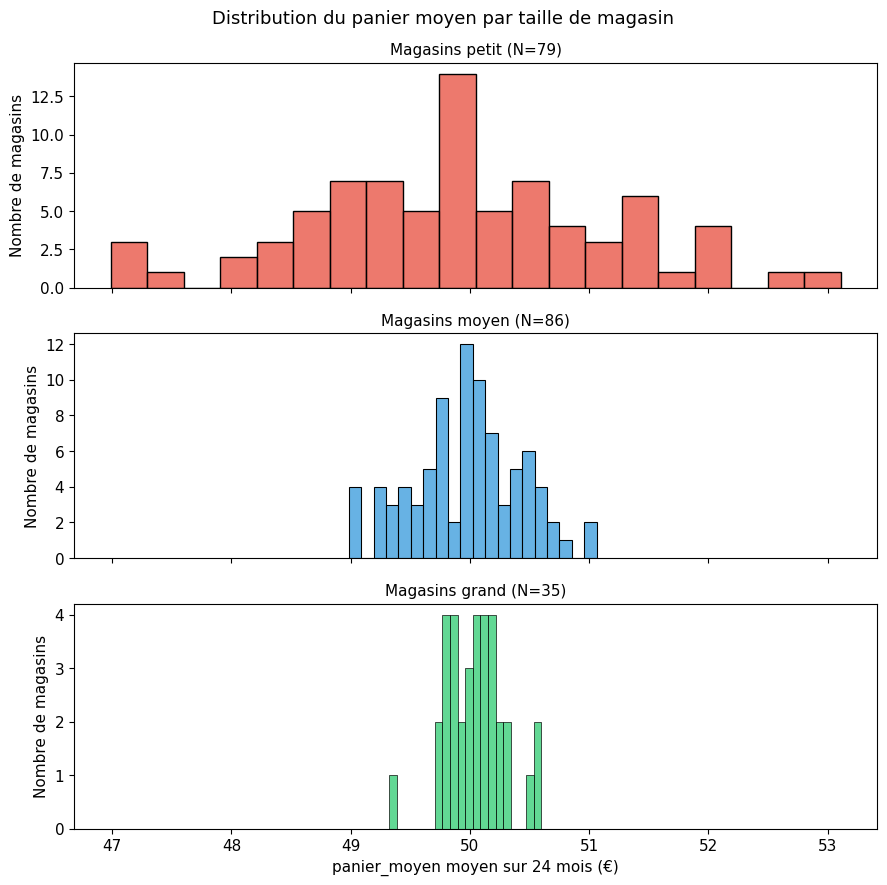

In [7]:
# ─────────────────────────────────────────────
# Figure 1 — Distribution du panier moyen par taille de magasin
# ─────────────────────────────────────────────
colors_sc0 = {'petit': '#e74c3c', 'moyen': '#3498db', 'grand': '#2ecc71'}
tailles_ordre = ['petit', 'moyen', 'grand']

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
for ax, taille in zip(axes, tailles_ordre):
    subset = agg_sc0[agg_sc0['taille'] == taille]
    sns.histplot(data=subset, x='panier_moyen_moy', ax=ax,
                 color=colors_sc0[taille], bins=20)
    ax.set_title(f'Magasins {taille} (N={len(subset)})', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Nombre de magasins')

axes[-1].set_xlabel('panier_moyen moyen sur 24 mois (€)')
fig.suptitle('Distribution du panier moyen par taille de magasin', fontsize=13)
plt.tight_layout()
fig.savefig('figures/sc0_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

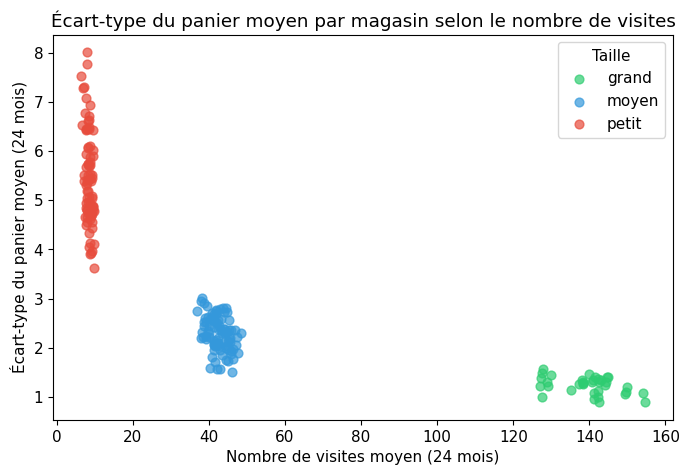

In [8]:
# ─────────────────────────────────────────────
# Figure 2 — Variance du panier moyen vs affluence
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for taille, grp in agg_sc0.groupby('taille'):
    ax.scatter(grp['nb_visites_moy'], grp['panier_moyen_std'],
               color=colors_sc0[taille], label=taille, alpha=0.7, s=40)

ax.set_xlabel('Nombre de visites moyen (24 mois)')
ax.set_ylabel('Écart-type du panier moyen (24 mois)')
ax.set_title('Écart-type du panier moyen par magasin selon le nombre de visites')
ax.legend(title='Taille')
fig.savefig('figures/sc0_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

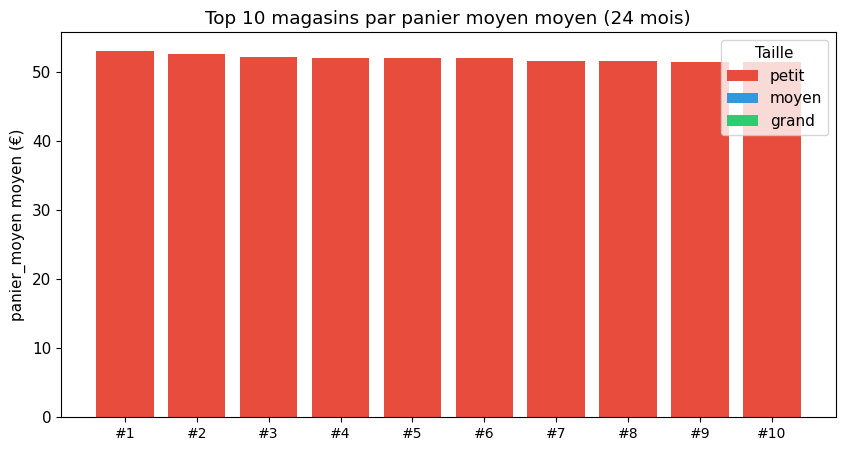

Top 10 : 10/10 petits magasins (100%)


In [9]:
# ─────────────────────────────────────────────
# Figure 3 — Top 10 magasins par panier moyen (analyse naïve)
# ─────────────────────────────────────────────
top10 = agg_sc0.nlargest(10, 'panier_moyen_moy').reset_index(drop=True)
bar_colors = [colors_sc0[t] for t in top10['taille']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(top10)), top10['panier_moyen_moy'], color=bar_colors)
ax.set_xticks(range(len(top10)))
ax.set_xticklabels([f"#{i+1}" for i in range(len(top10))], fontsize=10)
ax.set_ylabel('panier_moyen moyen (€)')
ax.set_title('Top 10 magasins par panier moyen moyen (24 mois)')

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(facecolor=colors_sc0[t], label=t) for t in tailles_ordre],
    title='Taille'
)
fig.savefig('figures/sc0_top10.png', dpi=150, bbox_inches='tight')
plt.show()

n_petits_top10 = (top10['taille'] == 'petit').sum()
print(f"Top 10 : {n_petits_top10}/10 petits magasins ({100*n_petits_top10//10}%)")

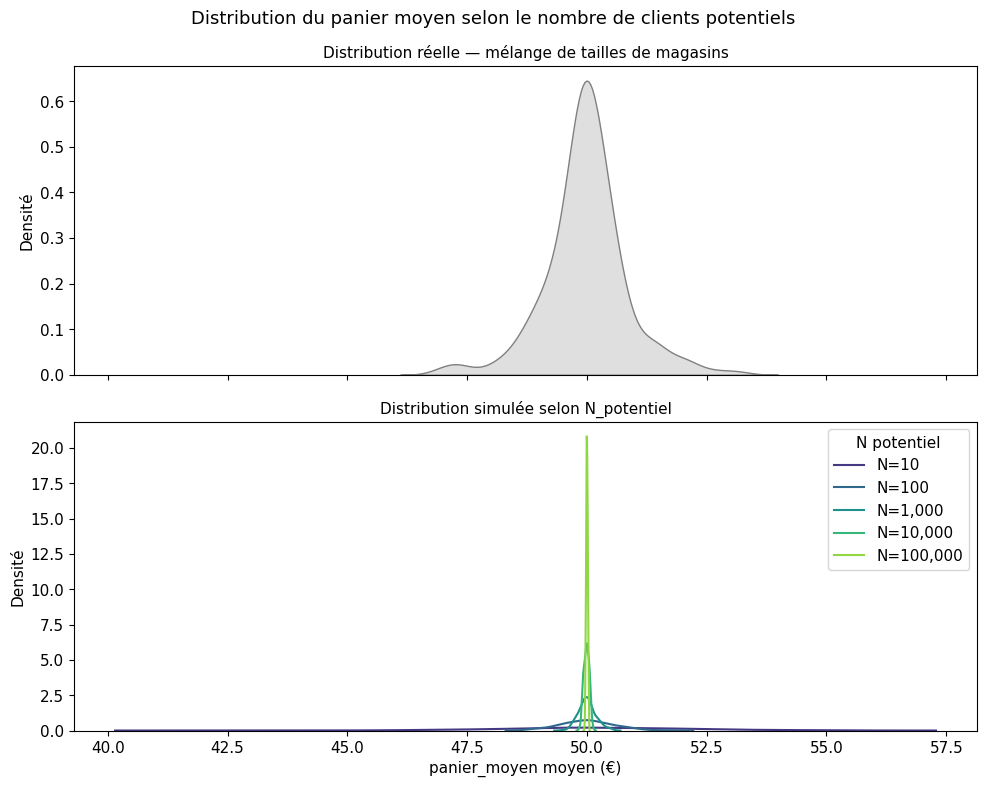

In [10]:
# ─────────────────────────────────────────────
# Figure 4 — Mécanisme : loi des grands nombres
# ─────────────────────────────────────────────
# CRITIQUE : rng_fig4 LOCAL — ne jamais utiliser le rng global ici
# (cela décalerait l'état du générateur pour les scénarios 1-3)
rng_fig4 = np.random.default_rng(SEED + 4)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Rang 1 (haut) : KDE de la distribution réelle (mélange petit/moyen/grand)
sns.kdeplot(data=agg_sc0['panier_moyen_moy'], ax=axes[0],
            fill=True, color='gray', label='Données réelles')
axes[0].set_title('Distribution réelle — mélange de tailles de magasins', fontsize=11)
axes[0].set_ylabel('Densité')
axes[0].set_xlabel('')

# Rang 2 (bas) : KDE overlay pour N = 10, 100, 1000, 10000, 100000
N_values = [10, 100, 1000, 10000, 100000]
palette_fig4 = sns.color_palette('viridis', len(N_values))

for N, color in zip(N_values, palette_fig4):
    params_sim = {**PARAMS, 'n_petit': N, 'n_moyen': N, 'n_grand': N}
    sim_df = generate_base_panel(params_sim, rng_fig4)
    sim_df['pub'] = 0
    sim_df = compute_outcomes(sim_df, params_sim, rng_fig4)
    agg_sim = sim_df.groupby('magasin_id')['panier_moyen'].mean()
    sns.kdeplot(data=agg_sim.dropna(), ax=axes[1],
                label=f'N={N:,}', color=color, warn_singular=False)

axes[1].set_title('Distribution simulée selon N_potentiel', fontsize=11)
axes[1].set_xlabel('panier_moyen moyen (€)')
axes[1].set_ylabel('Densité')
axes[1].legend(title='N potentiel')

fig.suptitle('Distribution du panier moyen selon le nombre de clients potentiels',
             fontsize=13)
plt.tight_layout()
fig.savefig('figures/sc0_loi_grands_nombres.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Pattern DAG

Démonstration du pattern NetworkX utilisé dans tous les scénarios. Layout fixe via `pos` dict — jamais `spring_layout`.

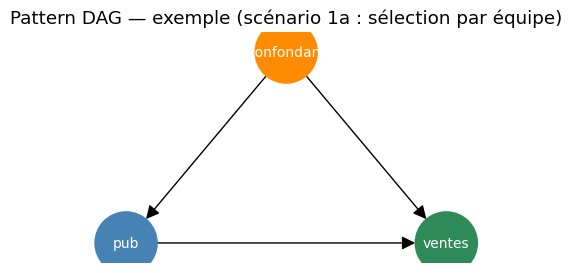

In [11]:
# Démonstration du pattern DAG utilisé dans tous les scénarios
G = nx.DiGraph()
G.add_edges_from([
    ('pub', 'ventes'),
    ('confondant', 'pub'),
    ('confondant', 'ventes'),
])
# FIXE — layout fixe via pos dict uniquement
pos = {'pub': (0, 0), 'ventes': (2, 0), 'confondant': (1, 1)}

fig, ax = plt.subplots(figsize=(5, 3))
nx.draw_networkx(G, pos, ax=ax,
                 node_color=['steelblue', 'seagreen', 'darkorange'],
                 node_size=2000, font_size=10, font_color='white',
                 arrows=True, arrowsize=20)
ax.axis('off')
ax.set_title('Pattern DAG — exemple (scénario 1a : sélection par équipe)')
fig.savefig('figures/dag_pattern_demo.png', dpi=150, bbox_inches='tight')
plt.show()